In [1]:
import polars as pl
from pathlib import Path

# Resolve data directory relative to this notebook location.
archive_dir = Path("ArchiveUserTraj")
if not archive_dir.exists():
    archive_dir = Path(
        r"C:\Users\wongb\user_trajectories_winter\494-user-trajectories\students\benedict\spring\ArchiveUserTraj"
    )

note_path = archive_dir / "sample_user_note_traj.parquet"
rating_path = archive_dir / "sample_user_rating_traj.parquet"
request_path = archive_dir / "sample_user_request_traj.parquet"

notes = (
    pl.read_parquet(note_path)
    .select(["noteAuthorParticipantId", "userMonth", "calendarMonth", "notesCreated"])
    .rename(
        {
            "noteAuthorParticipantId": "participantId",
            "notesCreated": "notesWritten",
        }
    )
)

ratings = (
    pl.read_parquet(rating_path)
    .select(["raterParticipantId", "userMonth", "calendarMonth", "notesRated"])
    .rename({"raterParticipantId": "participantId"})
)

requests = (
    pl.read_parquet(request_path)
    .select(["requesterParticipantId", "userMonth", "calendarMonth", "requestsMade"])
    .rename(
        {
            "requesterParticipantId": "participantId",
            "requestsMade": "notesRequested",
        }
    )
)

joined_chronological = (
    notes.join(
        ratings,
        on=["participantId", "userMonth", "calendarMonth"],
        how="full",
        coalesce=True,
    )
    .join(
        requests,
        on=["participantId", "userMonth", "calendarMonth"],
        how="full",
        coalesce=True,
    )
    .with_columns(
        [
            pl.col("notesWritten").fill_null(0),
            pl.col("notesRated").fill_null(0),
            pl.col("notesRequested").fill_null(0),
        ]
    )
    .sort(["participantId", "calendarMonth", "userMonth"])
)

# Save the chronological joined table before further aggregation.
joined_output_path = archive_dir / "user_month_actions_chronological.parquet"
joined_chronological.write_parquet(joined_output_path)

user_month_actions = (
    joined_chronological.group_by(["participantId", "userMonth", "calendarMonth"])
    .agg(
        [
            pl.sum("notesWritten").alias("notesWritten"),
            pl.sum("notesRated").alias("notesRated"),
            pl.sum("notesRequested").alias("notesRequested"),
        ]
    )
    .sort(["participantId", "calendarMonth", "userMonth"])
)

aggregate_output_path = archive_dir / "user_month_actions_aggregated.parquet"
user_month_actions.write_parquet(aggregate_output_path)

print(f"Saved chronological join to: {joined_output_path}")
print(f"Saved user-month aggregate to: {aggregate_output_path}")
user_month_actions.head()

Saved chronological join to: ArchiveUserTraj\user_month_actions_chronological.parquet
Saved user-month aggregate to: ArchiveUserTraj\user_month_actions_aggregated.parquet


participantId,userMonth,calendarMonth,notesWritten,notesRated,notesRequested
str,i32,str,u32,u32,u32
"""000AE77955227AE8D52CB70BA3FB64…",0,"""2025-12""",0,0,1
"""000C7AC0F2AE15FB6C478257825D41…",0,"""2025-11""",0,0,1
"""0014F9BA334FB10689F9D089BF4791…",0,"""2025-08""",0,0,1
"""00167DE211B4D41B0E054EFD79A977…",0,"""2025-11""",0,0,1
"""00167DE211B4D41B0E054EFD79A977…",1,"""2025-12""",0,0,1


In [2]:
main_df = pl.read_parquet(
    r"C:\Users\wongb\user_trajectories_winter\494-user-trajectories\students\benedict\spring\ArchiveUserTraj\user_month_actions_aggregated.parquet"
)

# Parse calendar month for month-wise panel expansion.
main_df_dates = main_df.with_columns(
    pl.col("calendarMonth").str.strptime(pl.Date, "%Y-%m").alias("calendarDate")
)

user_starts = main_df_dates.group_by("participantId").agg(
    [
        pl.col("calendarDate").min().alias("firstCalendarDate"),
        pl.col("userMonth").min().cast(pl.Int64).alias("firstUserMonth"),
    ]
)

global_max_calendar = main_df_dates.select(pl.col("calendarDate").max()).row(0)[0]
global_min_calendar = user_starts.select(pl.col("firstCalendarDate").min()).row(0)[0]

all_months = pl.DataFrame(
    {
        "calendarDate": pl.date_range(
            start=global_min_calendar,
            end=global_max_calendar,
            interval="1mo",
            eager=True,
        )
    }
)

# Build a complete panel from each user's first observed month to the global max month.
panel_index = (
    user_starts.select("participantId")
    .join(all_months, how="cross")
    .join(user_starts, on="participantId", how="left")
    .filter(pl.col("calendarDate") >= pl.col("firstCalendarDate"))
    .with_columns(
        (
            (pl.col("calendarDate").dt.year() - pl.col("firstCalendarDate").dt.year()) * 12
            + (pl.col("calendarDate").dt.month() - pl.col("firstCalendarDate").dt.month())
        ).alias("monthOffset")
    )
    .with_columns(
        [
            (pl.col("firstUserMonth") + pl.col("monthOffset")).cast(pl.Int64).alias("userMonth"),
            pl.col("calendarDate").dt.strftime("%Y-%m").alias("calendarMonth"),
        ]
    )
    .select(["participantId", "userMonth", "calendarMonth"])
)

classified_panel_df = (
    panel_index.join(
        main_df.select(["participantId", "calendarMonth", "notesWritten", "notesRated", "notesRequested"]),
        on=["participantId", "calendarMonth"],
        how="left",
    )
    .with_columns(
        [
            pl.col("notesWritten").fill_null(0).cast(pl.Int64),
            pl.col("notesRated").fill_null(0).cast(pl.Int64),
            pl.col("notesRequested").fill_null(0).cast(pl.Int64),
        ]
    )
    .with_columns(
        [
            (pl.col("notesWritten") == 1).cast(pl.Int8).alias("single_note_writer"),
            (pl.col("notesWritten").is_between(2, 9, closed="both")).cast(pl.Int8).alias("single_digit_writer"),
            (pl.col("notesWritten") >= 10).cast(pl.Int8).alias("double_digit_writer"),
            ((pl.col("notesWritten") == 0) & (pl.col("notesRated") == 1)).cast(pl.Int8).alias("single_note_rater"),
            ((pl.col("notesWritten") == 0) & pl.col("notesRated").is_between(2, 9, closed="both")).cast(pl.Int8).alias("single_digit_rater"),
            ((pl.col("notesWritten") == 0) & (pl.col("notesRated") >= 10)).cast(pl.Int8).alias("double_digit_rater"),
            ((pl.col("notesWritten") == 0) & (pl.col("notesRated") == 0) & (pl.col("notesRequested") == 1)).cast(pl.Int8).alias("single_post_requestor"),
            ((pl.col("notesWritten") == 0) & (pl.col("notesRated") == 0) & pl.col("notesRequested").is_between(2, 9, closed="both")).cast(pl.Int8).alias("single_digit_requestor"),
            ((pl.col("notesWritten") == 0) & (pl.col("notesRated") == 0) & (pl.col("notesRequested") >= 10)).cast(pl.Int8).alias("double_digit_requestor"),
            ((pl.col("notesWritten") == 0) & (pl.col("notesRated") == 0) & (pl.col("notesRequested") == 0)).cast(pl.Int8).alias("not_active"),
        ]
    )
    .with_columns(
        pl.when(pl.col("single_note_writer") == 1)
        .then(pl.lit("single_note_writer"))
        .when(pl.col("single_digit_writer") == 1)
        .then(pl.lit("single_digit_writer"))
        .when(pl.col("double_digit_writer") == 1)
        .then(pl.lit("double_digit_writer"))
        .when(pl.col("single_note_rater") == 1)
        .then(pl.lit("single_note_rater"))
        .when(pl.col("single_digit_rater") == 1)
        .then(pl.lit("single_digit_rater"))
        .when(pl.col("double_digit_rater") == 1)
        .then(pl.lit("double_digit_rater"))
        .when(pl.col("single_post_requestor") == 1)
        .then(pl.lit("single_post_requestor"))
        .when(pl.col("single_digit_requestor") == 1)
        .then(pl.lit("single_digit_requestor"))
        .when(pl.col("double_digit_requestor") == 1)
        .then(pl.lit("double_digit_requestor"))
        .otherwise(pl.lit("not_active"))
        .alias("activity_class")
    )
    .sort(["participantId", "calendarMonth", "userMonth"])
)

classified_output_path = archive_dir / "user_month_actions_panel_classified.parquet"
classified_panel_df.write_parquet(classified_output_path)

print(f"Saved classified panel to: {classified_output_path}")
print(classified_panel_df.shape)
classified_panel_df.head()

Saved classified panel to: ArchiveUserTraj\user_month_actions_panel_classified.parquet
(294573, 17)


participantId,userMonth,calendarMonth,notesWritten,notesRated,notesRequested,single_note_writer,single_digit_writer,double_digit_writer,single_note_rater,single_digit_rater,double_digit_rater,single_post_requestor,single_digit_requestor,double_digit_requestor,not_active,activity_class
str,i64,str,i64,i64,i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str
"""000AE77955227AE8D52CB70BA3FB64…",0,"""2025-12""",0,0,1,0,0,0,0,0,0,1,0,0,0,"""single_post_requestor"""
"""000AE77955227AE8D52CB70BA3FB64…",1,"""2026-01""",0,0,0,0,0,0,0,0,0,0,0,0,1,"""not_active"""
"""000AE77955227AE8D52CB70BA3FB64…",2,"""2026-02""",0,0,0,0,0,0,0,0,0,0,0,0,1,"""not_active"""
"""000C7AC0F2AE15FB6C478257825D41…",0,"""2025-11""",0,0,1,0,0,0,0,0,0,1,0,0,0,"""single_post_requestor"""
"""000C7AC0F2AE15FB6C478257825D41…",1,"""2025-12""",0,0,0,0,0,0,0,0,0,0,0,0,1,"""not_active"""


In [8]:
binary_cols = [
    "single_note_writer",
    "single_digit_writer",
    "double_digit_writer",
    "single_note_rater",
    "single_digit_rater",
    "double_digit_rater",
    "single_post_requestor",
    "single_digit_requestor",
    "double_digit_requestor",
    "not_active",
]

violations = (
    classified_panel_df.with_columns(pl.sum_horizontal([pl.col(c) for c in binary_cols]).alias("num_active_classes"))
    .filter(pl.col("num_active_classes") != 1)
)

rows_breaking_exclusivity = violations.height
users_breaking_exclusivity = violations.select(pl.col("participantId").n_unique()).item()

print(f"Rows breaking exclusivity: {rows_breaking_exclusivity}")
print(f"Users with at least one violating month: {users_breaking_exclusivity}")
violations.select(["participantId", "calendarMonth", "userMonth", "num_active_classes"] + binary_cols).head()

Rows breaking exclusivity: 0
Users with at least one violating month: 0


participantId,calendarMonth,userMonth,num_active_classes,single_note_writer,single_digit_writer,double_digit_writer,single_note_rater,single_digit_rater,double_digit_rater,single_post_requestor,single_digit_requestor,double_digit_requestor,not_active
str,str,i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8


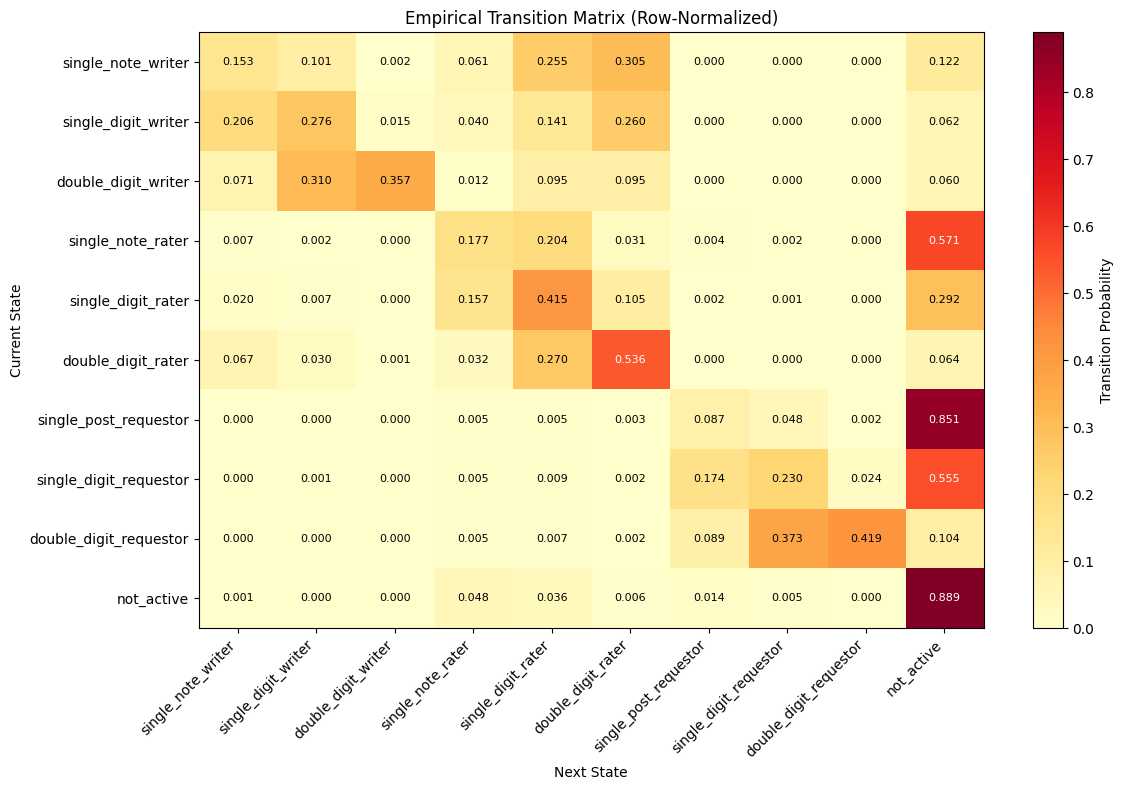

activity_class,single_note_writer,single_digit_writer,double_digit_writer,single_note_rater,single_digit_rater,double_digit_rater,single_post_requestor,single_digit_requestor,double_digit_requestor,not_active
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""single_note_writer""",0.153061,0.100907,0.00189,0.061224,0.255102,0.304989,0.000378,0.000378,0.0,0.122071
"""single_digit_writer""",0.206306,0.275531,0.015079,0.039753,0.141193,0.259767,0.0,0.0,0.0,0.062371
"""double_digit_writer""",0.071429,0.309524,0.357143,0.011905,0.095238,0.095238,0.0,0.0,0.0,0.059524
"""single_note_rater""",0.007306,0.002389,0.000092,0.177219,0.204236,0.03106,0.004181,0.002343,0.000138,0.571035
"""single_digit_rater""",0.020062,0.007138,0.000406,0.157008,0.415406,0.104706,0.002097,0.001015,0.000169,0.291992
"""double_digit_rater""",0.066794,0.030061,0.000733,0.031967,0.270401,0.53611,0.000073,0.000147,0.0,0.063714
"""single_post_requestor""",0.000292,0.000058,0.0,0.005255,0.004846,0.002511,0.08671,0.047764,0.001518,0.851045
"""single_digit_requestor""",0.000373,0.00056,0.0,0.005039,0.008772,0.002426,0.174132,0.230123,0.023516,0.555058
"""double_digit_requestor""",0.0,0.0,0.0,0.004819,0.007229,0.00241,0.089157,0.373494,0.419277,0.103614


In [3]:
import matplotlib.pyplot as plt
import numpy as np

states = [
    "single_note_writer",
    "single_digit_writer",
    "double_digit_writer",
    "single_note_rater",
    "single_digit_rater",
    "double_digit_rater",
    "single_post_requestor",
    "single_digit_requestor",
    "double_digit_requestor",
    "not_active",
]

# Build month-to-next-month transitions within each user trajectory.
transitions = (
    classified_panel_df.sort(["participantId", "userMonth"])
    .with_columns(
        [
            pl.col("activity_class").shift(-1).over("participantId").alias("next_state"),
            pl.col("userMonth").shift(-1).over("participantId").alias("next_userMonth"),
        ]
    )
    .filter(pl.col("next_state").is_not_null() & ((pl.col("next_userMonth") - pl.col("userMonth")) == 1))
    .select(["activity_class", "next_state"])
)

transition_counts = (
    transitions.group_by(["activity_class", "next_state"]).len().rename({"len": "count"})
)

# Ensure all 10x10 state pairs exist, then compute row-normalized transition probabilities.
state_grid = (
    pl.DataFrame({"activity_class": states})
    .join(pl.DataFrame({"next_state": states}), how="cross")
)

transition_full = (
    state_grid.join(transition_counts, on=["activity_class", "next_state"], how="left")
    .with_columns(pl.col("count").fill_null(0).cast(pl.Int64))
)

transition_matrix_long = (
    transition_full.join(
        transition_full.group_by("activity_class").agg(pl.col("count").sum().alias("row_total")),
        on="activity_class",
        how="left",
    )
    .with_columns(
        pl.when(pl.col("row_total") > 0)
        .then(pl.col("count") / pl.col("row_total"))
        .otherwise(0.0)
        .alias("probability")
    )
)

transition_matrix = (
    transition_matrix_long.select(["activity_class", "next_state", "probability"])
    .pivot(index="activity_class", on="next_state", values="probability", aggregate_function="sum")
)

# Reorder rows/columns to match the canonical state order for plotting.
state_order = pl.DataFrame({
    "activity_class": states,
    "state_order": list(range(len(states))),
})

transition_matrix_ordered = (
    transition_matrix.select(["activity_class"] + states)
    .join(state_order, on="activity_class", how="left")
    .sort("state_order")
    .drop("state_order")
)

heat_values = transition_matrix_ordered.select(states).to_numpy()

plt.figure(figsize=(12, 8))
img = plt.imshow(heat_values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=max(1e-9, float(np.max(heat_values))))
plt.colorbar(img, label="Transition Probability")
plt.xticks(ticks=np.arange(len(states)), labels=states, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(states)), labels=transition_matrix_ordered["activity_class"].to_list())

# Annotate each cell with its probability value.
for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        value = heat_values[i, j]
        text_color = "white" if value > 0.5 else "black"
        plt.text(j, i, f"{value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

plt.title("Empirical Transition Matrix (Row-Normalized)")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.show()

transition_matrix_ordered

In [20]:
from math import lgamma

import numpy as np

# Fallback in case scipy is unavailable in the kernel.
try:
    from scipy.special import gammaln
except Exception:
    gammaln = np.vectorize(lgamma)

states = [
    "single_note_writer",
    "single_digit_writer",
    "double_digit_writer",
    "single_note_rater",
    "single_digit_rater",
    "double_digit_rater",
    "single_post_requestor",
    "single_digit_requestor",
    "double_digit_requestor",
    "not_active",
]

state_ref = pl.DataFrame(
    {
        "state": states,
        "state_idx": list(range(len(states))),
    }
)

# Build user-level month-to-month transitions.
user_transitions = (
    classified_panel_df.sort(["participantId", "userMonth"])
    .with_columns(
        [
            pl.col("activity_class").shift(-1).over("participantId").alias("next_state"),
            pl.col("userMonth").shift(-1).over("participantId").alias("next_userMonth"),
        ]
    )
    .filter(pl.col("next_state").is_not_null() & ((pl.col("next_userMonth") - pl.col("userMonth")) == 1))
    .select(
        [
            "participantId",
            pl.col("activity_class").alias("from_state"),
            pl.col("next_state").alias("to_state"),
        ]
    )
)

# Population transition counts C(i->j).
pop_counts = user_transitions.group_by(["from_state", "to_state"]).len().rename({"len": "count"})
pop_wide = (
    pl.DataFrame({"from_state": states})
    .join(pl.DataFrame({"to_state": states}), how="cross")
    .join(pop_counts, on=["from_state", "to_state"], how="left")
    .with_columns(pl.col("count").fill_null(0).cast(pl.Float64))
    .pivot(index="from_state", on="to_state", values="count", aggregate_function="sum")
    .select(["from_state"] + states)
)

pop_matrix = pop_wide.select(states).to_numpy()
pop_totals = pop_matrix.sum(axis=1)

# User-level transition counts c_u(i->j), expanded to all users x all from-states.
user_counts = (
    user_transitions.group_by(["participantId", "from_state", "to_state"]).len().rename({"len": "count"})
    .pivot(index=["participantId", "from_state"], on="to_state", values="count", aggregate_function="sum")
)

users_df = classified_panel_df.select("participantId").unique()
user_from_grid = users_df.join(pl.DataFrame({"from_state": states}), how="cross")

user_counts_wide = user_from_grid.join(user_counts, on=["participantId", "from_state"], how="left").with_columns(
    [pl.col(s).fill_null(0).cast(pl.Float64) for s in states]
)

user_counts_wide = user_counts_wide.join(
    state_ref.rename({"state": "from_state"}), on="from_state", how="left"
)

X = user_counts_wide.select(states).to_numpy()  # shape: (n_user_from, 10)
from_idx = user_counts_wide.select("state_idx").to_numpy().ravel().astype(int)
row_totals = X.sum(axis=1)


# Dirichlet-Multinomial log-likelihood objective summed over users and from-states.
def total_log_likelihood(kappa: float) -> float:
    eps = 1e-9
    ll = 0.0

    for i in range(len(states)):
        mask = from_idx == i
        if not np.any(mask):
            continue

        Xi = X[mask]
        ni = row_totals[mask]

        # Normalize population row into a probability prior, then scale by kappa.
        p_i = pop_matrix[i] / (pop_totals[i] + eps)
        alpha = kappa * p_i + eps
        alpha0 = alpha.sum()

        group_ll = (
            Xi.shape[0] * gammaln(alpha0)
            - np.sum(gammaln(alpha0 + ni))
            + np.sum(gammaln(Xi + alpha))
            - Xi.shape[0] * np.sum(gammaln(alpha))
        )
        ll += float(group_ll)

    return ll


# Grid-search MLE for kappa on log-scale (coarse + local refinement).
grid_coarse = np.logspace(-3, 2, 80)
ll_coarse = np.array([total_log_likelihood(float(k)) for k in grid_coarse])
best_idx = int(np.argmax(ll_coarse))
kappa_coarse = float(grid_coarse[best_idx])

lower = max(1e-4, kappa_coarse / 3.0)
upper = kappa_coarse * 3.0
grid_fine = np.logspace(np.log10(lower), np.log10(upper), 120)
ll_fine = np.array([total_log_likelihood(float(k)) for k in grid_fine])
best_fine_idx = int(np.argmax(ll_fine))

kappa_mle = float(grid_fine[best_fine_idx])
loglik_mle = float(ll_fine[best_fine_idx])

print(f"Estimated kappa (MLE): {kappa_mle:.6f}")
print(f"Total log-likelihood at MLE: {loglik_mle:.2f}")

Estimated kappa (MLE): 13.364488
Total log-likelihood at MLE: -192133.73


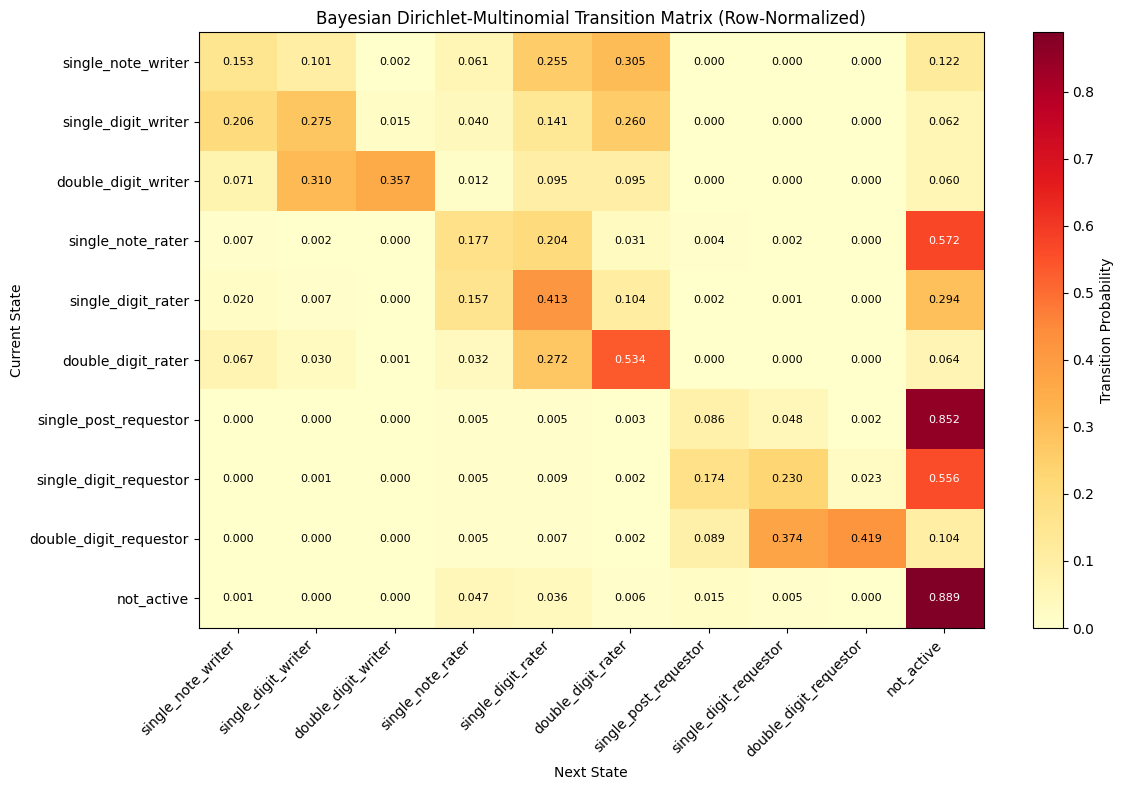

activity_class,single_note_writer,single_digit_writer,double_digit_writer,single_note_rater,single_digit_rater,double_digit_rater,single_post_requestor,single_digit_requestor,double_digit_requestor,not_active
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""single_note_writer""",0.15296,0.100869,0.00189,0.061237,0.255172,0.304995,0.000378,0.000378,0.0,0.122121
"""single_digit_writer""",0.206319,0.275393,0.015073,0.039768,0.141246,0.259811,0.0,0.0,0.0,0.062391
"""double_digit_writer""",0.07143,0.309532,0.357128,0.011904,0.09524,0.095239,0.0,0.0,0.0,0.059526
"""single_note_rater""",0.007301,0.002395,0.000093,0.176567,0.204149,0.031103,0.004184,0.002347,0.000139,0.571722
"""single_digit_rater""",0.020027,0.007163,0.000413,0.157342,0.413292,0.10445,0.002108,0.001021,0.00017,0.294014
"""double_digit_rater""",0.066804,0.030099,0.000735,0.032203,0.271706,0.534155,0.000074,0.000149,0.0,0.064075
"""single_post_requestor""",0.000292,0.000059,0.0,0.005258,0.00485,0.002515,0.086304,0.047623,0.001513,0.851585
"""single_digit_requestor""",0.000374,0.000561,0.0,0.005043,0.008783,0.00243,0.174167,0.229681,0.023454,0.555507
"""double_digit_requestor""",0.0,0.0,0.0,0.00482,0.00723,0.00241,0.089173,0.373531,0.419205,0.103631


In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Bayesian posterior using fitted kappa from Cell 5 with normalized population prior p_i.
# p_i(j) = C(i->j) / C(i->.)
# posterior_u(i->j) = (kappa * p_i(j) + c_u(i->j)) / (kappa + c_u(i->.))
eps = 1e-9
pop_prob_matrix = pop_matrix / (pop_totals[:, None] + eps)

posterior_rows = (kappa_mle * pop_prob_matrix[from_idx, :] + X) / (
    kappa_mle + row_totals[:, None]
)

# Aggregate user-level posterior matrices by averaging across users for each from-state.
bayes_matrix = np.zeros((len(states), len(states)), dtype=float)
for i in range(len(states)):
    mask = from_idx == i
    if np.any(mask):
        bayes_matrix[i, :] = posterior_rows[mask].mean(axis=0)

bayes_transition_matrix_ordered = pl.DataFrame(
    {"activity_class": states, **{states[j]: bayes_matrix[:, j] for j in range(len(states))}}
)

heat_values = bayes_transition_matrix_ordered.select(states).to_numpy()

plt.figure(figsize=(12, 8))
img = plt.imshow(
    heat_values,
    cmap="YlOrRd",
    aspect="auto",
    vmin=0,
    vmax=max(1e-9, float(np.max(heat_values))),
)
plt.colorbar(img, label="Transition Probability")
plt.xticks(ticks=np.arange(len(states)), labels=states, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(states)), labels=states)

for i in range(heat_values.shape[0]):
    for j in range(heat_values.shape[1]):
        value = heat_values[i, j]
        text_color = "white" if value > 0.5 else "black"
        plt.text(j, i, f"{value:.3f}", ha="center", va="center", color=text_color, fontsize=8)

plt.title("Bayesian Dirichlet-Multinomial Transition Matrix (Row-Normalized)")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.show()

bayes_transition_matrix_ordered

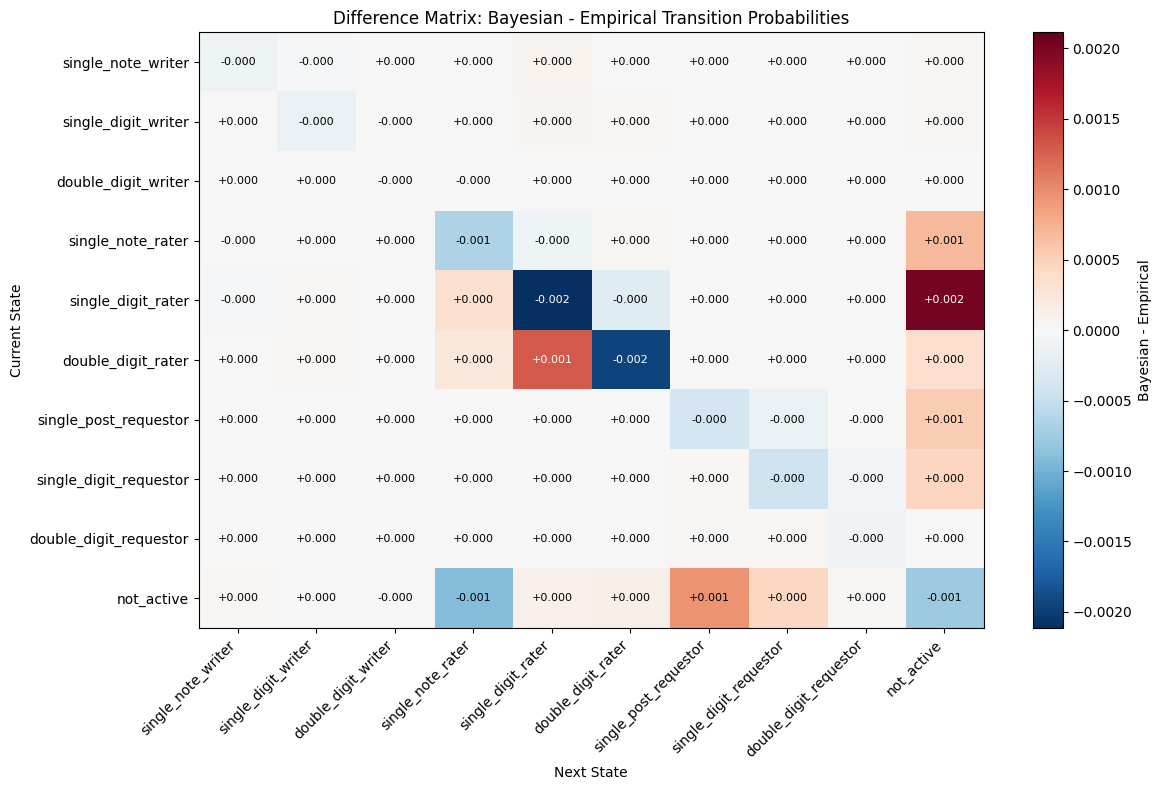

activity_class,single_note_writer,single_digit_writer,double_digit_writer,single_note_rater,single_digit_rater,double_digit_rater,single_post_requestor,single_digit_requestor,double_digit_requestor,not_active
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""single_note_writer""",-0.000101,-0.000038,3.7633e-7,0.000012,0.00007,0.000006,4.6361e-7,2.3706e-7,0.0,0.00005
"""single_digit_writer""",0.000013,-0.000138,-0.000006,0.000014,0.000054,0.000044,0.0,0.0,0.0,0.00002
"""double_digit_writer""",0.000002,0.000008,-0.000015,-3.5073e-7,0.000002,0.000001,0.0,0.0,0.0,0.000002
"""single_note_rater""",-0.000005,0.000006,7.2883e-7,-0.000653,-0.000088,0.000043,0.000003,0.000004,0.000001,0.000688
"""single_digit_rater""",-0.000034,0.000024,0.000007,0.000334,-0.002115,-0.000256,0.00001,0.000006,7.1351e-7,0.002022
"""double_digit_rater""",0.000011,0.000038,0.000002,0.000236,0.001305,-0.001955,9.4252e-7,0.000002,0.0,0.000361
"""single_post_requestor""",4.8313e-8,1.4559e-7,0.0,0.000003,0.000004,0.000004,-0.000407,-0.00014,-0.000005,0.00054
"""single_digit_requestor""",6.7123e-7,7.8029e-7,0.0,0.000004,0.000011,0.000004,0.000035,-0.000442,-0.000063,0.000449
"""double_digit_requestor""",0.0,0.0,0.0,4.4743e-7,8.2368e-7,6.0280e-7,0.000017,0.000037,-0.000072,0.000016


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Compare Bayesian vs empirical transition matrices from previous cells.
empirical_matrix = transition_matrix_ordered.select(["activity_class"] + states)
bayesian_matrix = bayes_transition_matrix_ordered.select(["activity_class"] + states)

diff_matrix = (
    bayesian_matrix.join(empirical_matrix, on="activity_class", suffix="_emp")
    .select(
        [
            "activity_class",
            *[
                (pl.col(s) - pl.col(f"{s}_emp")).alias(s)
                for s in states
            ],
        ]
    )
)

diff_values = diff_matrix.select(states).to_numpy()
max_abs = float(np.max(np.abs(diff_values)))

plt.figure(figsize=(12, 8))
img = plt.imshow(diff_values, cmap="RdBu_r", aspect="auto", vmin=-max_abs, vmax=max_abs)
plt.colorbar(img, label="Bayesian - Empirical")
plt.xticks(ticks=np.arange(len(states)), labels=states, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(states)), labels=diff_matrix["activity_class"].to_list())

for i in range(diff_values.shape[0]):
    for j in range(diff_values.shape[1]):
        value = diff_values[i, j]
        text_color = "white" if abs(value) > max_abs * 0.55 else "black"
        plt.text(j, i, f"{value:+.3f}", ha="center", va="center", color=text_color, fontsize=8)

plt.title("Difference Matrix: Bayesian - Empirical Transition Probabilities")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.show()

diff_matrix

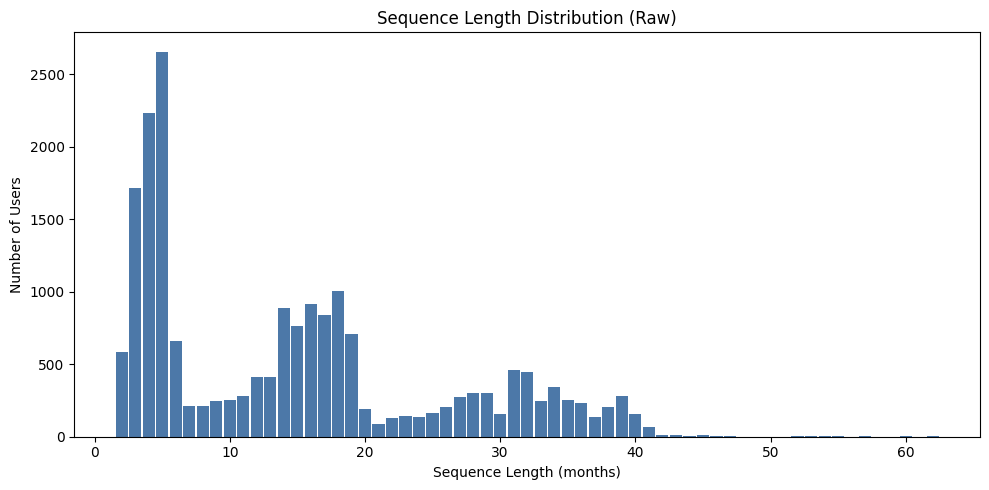

Total users: 20000
Total user-month rows: 294573
Min sequence length: 2
Q1 sequence length: 5.00
Median sequence length: 14.00
Mean sequence length: 14.73
Q3 sequence length: 20.00
Max sequence length: 62
Std sequence length: 11.19


sequence_length,num_users
u32,u32
2,584
3,1716
4,2231
5,2655
6,657
…,…
57,3
59,1
60,3


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Sequence length per user = number of user-month rows in the classified panel.
sequence_lengths = (
    classified_panel_df.group_by("participantId")
    .len()
    .rename({"len": "sequence_length"})
)

length_distribution = (
    sequence_lengths.group_by("sequence_length")
    .len()
    .rename({"len": "num_users"})
    .sort("sequence_length")
)

x = length_distribution["sequence_length"].to_numpy()
y = length_distribution["num_users"].to_numpy()

# Raw frequency bar chart only.
plt.figure(figsize=(10, 5))
plt.bar(x, y, color="#4C78A8", width=0.9)
plt.title("Sequence Length Distribution (Raw)")
plt.xlabel("Sequence Length (months)")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

# Extended metadata summary.
sl = sequence_lengths["sequence_length"]
print(f"Total users: {sequence_lengths.height}")
print(f"Total user-month rows: {int(sl.sum())}")
print(f"Min sequence length: {int(sl.min())}")
print(f"Q1 sequence length: {float(sl.quantile(0.25)):.2f}")
print(f"Median sequence length: {float(sl.median()):.2f}")
print(f"Mean sequence length: {float(sl.mean()):.2f}")
print(f"Q3 sequence length: {float(sl.quantile(0.75)):.2f}")
print(f"Max sequence length: {int(sl.max())}")
print(f"Std sequence length: {float(sl.std()):.2f}")

length_distribution

In [5]:
import plotly.graph_objects as go

# Build edge table from empirical transitions: include count + P(j|i).
empirical_edges = (
    transition_matrix_long.select(["activity_class", "next_state", "probability"])
    .join(
        transition_counts.rename({"activity_class": "activity_class", "next_state": "next_state"}),
        on=["activity_class", "next_state"],
        how="left",
    )
    .with_columns(pl.col("count").fill_null(0).cast(pl.Int64))
)

# Defensible filtering: both probability and minimum count thresholds.
filtered_edges = empirical_edges.filter(
    (pl.col("probability") >= 0.01) & (pl.col("count") >= 50)
)

if filtered_edges.height == 0:
    print("No transitions satisfy P(j|i) >= 0.01 and count >= 50.")
else:
    # Separate from/to node sets for clean left-to-right flow.
    from_nodes = [f"from: {s}" for s in states]
    to_nodes = [f"to: {s}" for s in states]
    node_labels = from_nodes + to_nodes

    # State color palette (source and target nodes share the same base color by state).
    state_colors_rgba = {
        "single_note_writer": "rgba(31,119,180,0.85)",
        "single_digit_writer": "rgba(23,190,207,0.85)",
        "double_digit_writer": "rgba(44,160,44,0.85)",
        "single_note_rater": "rgba(255,127,14,0.85)",
        "single_digit_rater": "rgba(214,39,40,0.85)",
        "double_digit_rater": "rgba(148,103,189,0.85)",
        "single_post_requestor": "rgba(140,86,75,0.85)",
        "single_digit_requestor": "rgba(227,119,194,0.85)",
        "double_digit_requestor": "rgba(127,127,127,0.85)",
        "not_active": "rgba(188,189,34,0.85)",
    }

    from_idx_map = {s: i for i, s in enumerate(states)}
    to_idx_map = {s: i + len(states) for i, s in enumerate(states)}

    sources = [from_idx_map[s] for s in filtered_edges["activity_class"].to_list()]
    targets = [to_idx_map[s] for s in filtered_edges["next_state"].to_list()]
    values = filtered_edges["count"].to_list()

    # Color links by source state for easier path tracing.
    link_colors = [state_colors_rgba[s] for s in filtered_edges["activity_class"].to_list()]

    node_colors = [state_colors_rgba[s] for s in states] + [state_colors_rgba[s] for s in states]

    hover_text = [
        f"{f} -> {t}<br>count={c}<br>P(j|i)={p:.3f}"
        for f, t, c, p in zip(
            filtered_edges["activity_class"].to_list(),
            filtered_edges["next_state"].to_list(),
            filtered_edges["count"].to_list(),
            filtered_edges["probability"].to_list(),
        )
    ]

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=10,
                    thickness=12,
                    line=dict(color="black", width=0.3),
                    label=node_labels,
                    color=node_colors,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color=link_colors,
                    customdata=hover_text,
                    hovertemplate="%{customdata}<extra></extra>",
                ),
            )
        ]
    )

    fig.update_layout(
        title_text="Empirical Transition Sankey (P(j|i) >= 0.01 and count >= 50)",
        font_size=11,
        width=1200,
        height=700,
    )

    fig.show()

    print(f"Transitions kept: {filtered_edges.height}")
    filtered_edges.sort(["activity_class", "next_state"])

Transitions kept: 40


In [ ]:
import plotly.graph_objects as go

# Build month-to-next-month transitions once, then slice by userMonth.
transitions_by_month = (
    classified_panel_df.sort(["participantId", "userMonth"])
    .with_columns(
        [
            pl.col("activity_class").shift(-1).over("participantId").alias("next_state"),
            pl.col("userMonth").shift(-1).over("participantId").alias("next_userMonth"),
        ]
    )
    .filter(pl.col("next_state").is_not_null() & ((pl.col("next_userMonth") - pl.col("userMonth")) == 1))
    .select(["participantId", "userMonth", pl.col("activity_class").alias("from_state"), "next_state"])
)

# Same visual mapping as Cell 9.
from_nodes = [f"from: {s}" for s in states]
to_nodes = [f"to: {s}" for s in states]
node_labels = from_nodes + to_nodes

state_colors_rgba = {
    "single_note_writer": "rgba(31,119,180,0.85)",
    "single_digit_writer": "rgba(23,190,207,0.85)",
    "double_digit_writer": "rgba(44,160,44,0.85)",
    "single_note_rater": "rgba(255,127,14,0.85)",
    "single_digit_rater": "rgba(214,39,40,0.85)",
    "double_digit_rater": "rgba(148,103,189,0.85)",
    "single_post_requestor": "rgba(140,86,75,0.85)",
    "single_digit_requestor": "rgba(227,119,194,0.85)",
    "double_digit_requestor": "rgba(127,127,127,0.85)",
    "not_active": "rgba(188,189,34,0.85)",
}

from_idx_map = {s: i for i, s in enumerate(states)}
to_idx_map = {s: i + len(states) for i, s in enumerate(states)}
node_colors = [state_colors_rgba[s] for s in states] + [state_colors_rgba[s] for s in states]


def build_slice_links(month_slice: int):
    slice_df = transitions_by_month.filter(pl.col("userMonth") == month_slice)

    if slice_df.height == 0:
        return {
            "source": [],
            "target": [],
            "value": [],
            "color": [],
            "customdata": [],
            "edges": pl.DataFrame({"from_state": [], "next_state": [], "count": [], "probability": []}),
        }

    counts = (
        slice_df.group_by(["from_state", "next_state"]).len().rename({"len": "count"})
    )

    full_grid = (
        pl.DataFrame({"from_state": states})
        .join(pl.DataFrame({"next_state": states}), how="cross")
        .join(counts, on=["from_state", "next_state"], how="left")
        .with_columns(pl.col("count").fill_null(0).cast(pl.Int64))
    )

    row_totals = full_grid.group_by("from_state").agg(pl.col("count").sum().alias("row_total"))

    edges = (
        full_grid.join(row_totals, on="from_state", how="left")
        .with_columns(
            pl.when(pl.col("row_total") > 0)
            .then(pl.col("count") / pl.col("row_total"))
            .otherwise(0.0)
            .alias("probability")
        )
        .filter((pl.col("probability") >= 0.01) & (pl.col("count") >= 50))
        .sort(["from_state", "next_state"])
    )

    sources = [from_idx_map[s] for s in edges["from_state"].to_list()]
    targets = [to_idx_map[s] for s in edges["next_state"].to_list()]
    values = edges["count"].to_list()
    link_colors = [state_colors_rgba[s] for s in edges["from_state"].to_list()]
    hover_text = [
        f"month={month_slice}<br>{f} -> {t}<br>count={c}<br>P(j|i)={p:.3f}"
        for f, t, c, p in zip(
            edges["from_state"].to_list(),
            edges["next_state"].to_list(),
            edges["count"].to_list(),
            edges["probability"].to_list(),
        )
    ]

    return {
        "source": sources,
        "target": targets,
        "value": values,
        "color": link_colors,
        "customdata": hover_text,
        "edges": edges,
    }

num_months = 40
months = list(range(num_months))
links_by_month = {m: build_slice_links(m) for m in months}

# Use month 0 as initial view.
initial_month = 0
initial_links = links_by_month[initial_month]

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=10,
                thickness=12,
                line=dict(color="black", width=0.3),
                label=node_labels,
                color=node_colors,
            ),
            link=dict(
                source=initial_links["source"],
                target=initial_links["target"],
                value=initial_links["value"],
                color=initial_links["color"],
                customdata=initial_links["customdata"],
                hovertemplate="%{customdata}<extra></extra>",
            ),
        )
    ],
    frames=[
        go.Frame(
            name=str(m),
            data=[
                go.Sankey(
                    node=dict(
                        pad=10,
                        thickness=12,
                        line=dict(color="black", width=0.3),
                        label=node_labels,
                        color=node_colors,
                    ),
                    link=dict(
                        source=links_by_month[m]["source"],
                        target=links_by_month[m]["target"],
                        value=links_by_month[m]["value"],
                        color=links_by_month[m]["color"],
                        customdata=links_by_month[m]["customdata"],
                        hovertemplate="%{customdata}<extra></extra>",
                    ),
                )
            ],
        )
        for m in months
    ],
)

steps = [
    {
        "method": "animate",
        "label": f"uMonth {m}",
        "args": [[str(m)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
    }
    for m in months
]

fig.update_layout(
    title_text=f"Empirical Sankey by User-Month Slice (0-{num_months - 1}), filters: P(j|i)>=0.01 and count>=50",
    font_size=11,
    width=1200,
    height=720,
    sliders=[
        {
            "active": 0,
            "currentvalue": {"prefix": "Slice: "},
            "pad": {"t": 45},
            "steps": steps,
        }
    ],
)

fig.show()

slice_counts = pl.DataFrame(
    {
        "userMonth": months,
        "transitions_kept": [links_by_month[m]["edges"].height for m in months],
    }
)

slice_counts

userMonth,transitions_kept
i64,i64
0,16
1,20
2,18
3,17
4,16
…,…
35,4
36,4
37,2


In [12]:
import plotly.graph_objects as go

# Build month-to-next-month transitions once, then slice by calendarMonth of the current state.
transitions_by_calendar = (
    classified_panel_df.sort(["participantId", "userMonth"])
.with_columns(
        [
            pl.col("activity_class").shift(-1).over("participantId").alias("next_state"),
            pl.col("userMonth").shift(-1).over("participantId").alias("next_userMonth"),
            pl.col("calendarMonth").shift(-1).over("participantId").alias("next_calendarMonth"),
        ]
    )
    .filter(
        pl.col("next_state").is_not_null()
        & ((pl.col("next_userMonth") - pl.col("userMonth")) == 1)
    )
    .select([
        "participantId",
        "calendarMonth",
        "next_calendarMonth",
        pl.col("activity_class").alias("from_state"),
        "next_state",
    ])
)

# Same visual mapping as Cell 10.
from_nodes = [f"from: {s}" for s in states]
to_nodes = [f"to: {s}" for s in states]
node_labels = from_nodes + to_nodes

state_colors_rgba = {
    "single_note_writer": "rgba(31,119,180,0.85)",
    "single_digit_writer": "rgba(23,190,207,0.85)",
    "double_digit_writer": "rgba(44,160,44,0.85)",
    "single_note_rater": "rgba(255,127,14,0.85)",
    "single_digit_rater": "rgba(214,39,40,0.85)",
    "double_digit_rater": "rgba(148,103,189,0.85)",
    "single_post_requestor": "rgba(140,86,75,0.85)",
    "single_digit_requestor": "rgba(227,119,194,0.85)",
    "double_digit_requestor": "rgba(127,127,127,0.85)",
    "not_active": "rgba(188,189,34,0.85)",
}

from_idx_map = {s: i for i, s in enumerate(states)}
to_idx_map = {s: i + len(states) for i, s in enumerate(states)}
node_colors = [state_colors_rgba[s] for s in states] + [state_colors_rgba[s] for s in states]


def build_slice_links(calendar_slice: str):
    slice_df = transitions_by_calendar.filter(pl.col("calendarMonth") == calendar_slice)

    if slice_df.height == 0:
        return {
            "source": [],
            "target": [],
            "value": [],
            "color": [],
            "customdata": [],
            "edges": pl.DataFrame({"from_state": [], "next_state": [], "count": [], "probability": []}),
        }

    counts = (
        slice_df.group_by(["from_state", "next_state"]).len().rename({"len": "count"})
    )

    full_grid = (
        pl.DataFrame({"from_state": states})
        .join(pl.DataFrame({"next_state": states}), how="cross")
        .join(counts, on=["from_state", "next_state"], how="left")
        .with_columns(pl.col("count").fill_null(0).cast(pl.Int64))
    )

    row_totals = full_grid.group_by("from_state").agg(pl.col("count").sum().alias("row_total"))
    count_threshold = 0
    edges = (
        full_grid.join(row_totals, on="from_state", how="left")
        .with_columns(
            pl.when(pl.col("row_total") > 0)
            .then(pl.col("count") / pl.col("row_total"))
            .otherwise(0.0)
            .alias("probability")
        )
        .filter((pl.col("probability") >= 0.01) & (pl.col("count") >= count_threshold))
        .sort(["from_state", "next_state"])
)

    sources = [from_idx_map[s] for s in edges["from_state"].to_list()]
    targets = [to_idx_map[s] for s in edges["next_state"].to_list()]
    values = edges["count"].to_list()
    link_colors = [state_colors_rgba[s] for s in edges["from_state"].to_list()]
    hover_text = [
        f"month={calendar_slice}<br>{f} -> {t}<br>count={c}<br>P(j|i)={p:.3f}"
        for f, t, c, p in zip(
            edges["from_state"].to_list(),
            edges["next_state"].to_list(),
            edges["count"].to_list(),
            edges["probability"].to_list(),
        )
    ]

    return {
        "source": sources,
        "target": targets,
        "value": values,
        "color": link_colors,
        "customdata": hover_text,
        "edges": edges,
    }

calendar_months = sorted(
    transitions_by_calendar.select("calendarMonth").unique().get_column("calendarMonth").to_list()
)

if len(calendar_months) == 0:
    print("No transitions available to plot.")
else:
    links_by_calendar = {m: build_slice_links(m) for m in calendar_months}

    # Use earliest calendar month as initial view.
    initial_month = calendar_months[0]
    initial_links = links_by_calendar[initial_month]

    fig = go.Figure(
        data=[
            go.Sankey(
                arrangement="snap",
                node=dict(
                    pad=10,
                    thickness=12,
                    line=dict(color="black", width=0.3),
                    label=node_labels,
                    color=node_colors,
                ),
                link=dict(
                    source=initial_links["source"],
                    target=initial_links["target"],
                    value=initial_links["value"],
                    color=initial_links["color"],
                    customdata=initial_links["customdata"],
                    hovertemplate="%{customdata}<extra></extra>",
                ),
            )
        ],
        frames=[
            go.Frame(
                name=m,
                data=[
                    go.Sankey(
                        node=dict(
                            pad=10,
                            thickness=12,
                            line=dict(color="black", width=0.3),
                            label=node_labels,
                            color=node_colors,
                        ),
                        link=dict(
                            source=links_by_calendar[m]["source"],
                            target=links_by_calendar[m]["target"],
                            value=links_by_calendar[m]["value"],
                            color=links_by_calendar[m]["color"],
                            customdata=links_by_calendar[m]["customdata"],
                            hovertemplate="%{customdata}<extra></extra>",
                        ),
                    )
                ],
            )
            for m in calendar_months
        ],
    )

    steps = [
        {
            "method": "animate",
            "label": m,
            "args": [[m], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
        }
        for m in calendar_months
    ]

    fig.update_layout(
        title_text="Empirical Sankey by Calendar Month (filters: P(j|i)>=0.01 and count>=50)",
        font_size=11,
        width=1200,
        height=720,
        sliders=[
            {
                "active": 0,
                "currentvalue": {"prefix": "Calendar month: "},
                "pad": {"t": 45},
                "steps": steps,
            }
        ],
    )

    fig.show()

    slice_counts = pl.DataFrame(
        {
            "calendarMonth": calendar_months,
            "transitions_kept": [links_by_calendar[m]["edges"].height for m in calendar_months],
        }
    )

    slice_counts